In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC_refactor/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC_refactor/code


# Dataset Introduction
We aimed to characterise the neural representations in the medial-frontal cortex (mFC) in mice during a complex route-planning task. Below we briefly outline our experimental methodology to give you a feel for the dataset. 



### Surgery & Electrophysiology 
We Implanted 6 mice with 6-shank silicon probes (Cambrdige Neurotech) in the left mFC (prelimibic) using custom-designed implants. 

### TODO
- repreprocess ephys data with IBL preprocessing and KS4 
- update cluster quality metrics
- Align 2D histology to Allen CCI coordinates and generate ephys anatomy summary 

### Task Design & Behavioural Performance

Mice recovered for 1 weeks after surgery and then underwent our standardised pretraining pipeline on a small 3x3 maze (see ```goalNav_mFC/pretraining``` for more details). During pretraining, subjects leared to navigate to cued goal locations (towers) and recieve water rewards. On each trial, a randomly selected tower was cued with a brief sounds and LED next to the reward port. The goal light stayed on while subjects then navigated to the goal tower and nose-poked into the tower's reward port to recieve a small water reward. This triggered a variable ITI period of 4-8 seconds before the next goal was cued. 

Subjects were then exposted to a series of larger 7x7 mazes (named "Maze 1", "Maze 2" and "Rooms Maze") where they performed the same task. Here the task became alot harder as paths to goal became longer and more complex due to the larger maze size and structure (see figure below). Mazes 1 & 2 were designed using a cutom genetic algorithm that generated maze structures which maximally decorrelated the shortest path (geodesic distance) and the euclidean distance between goal locations under a additional set of minimal constraints (see ```2.maze_design.ipynb```). This was designed to encourage subject's to navigate during an internal model of the maze (a la 'cognitive map') rather than just using vector navigation. The final Rooms Maze was inspired by work in hierarchical RL and resembed 4 "rooms" each connected by a single walk-way. 

A subset of 24-goal were used as goal locations during the main experiment (with some later days of training on each maze smaller subsets of 12 goals were used). This was to increase the number of trials where subjects were navigating to a given goal to aid with goal decoding analyses (subsets illustrated below). 

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


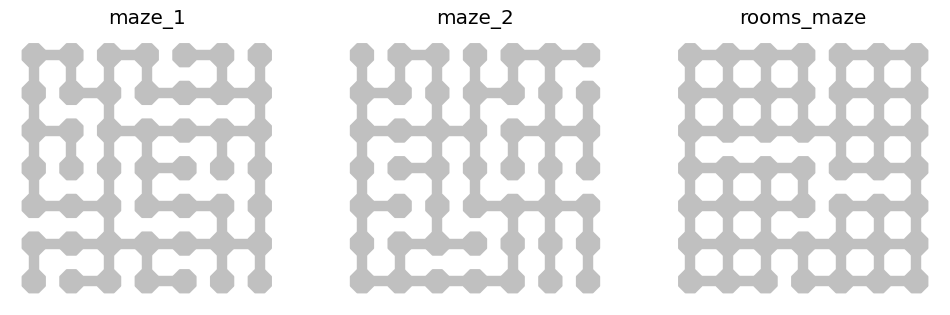

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


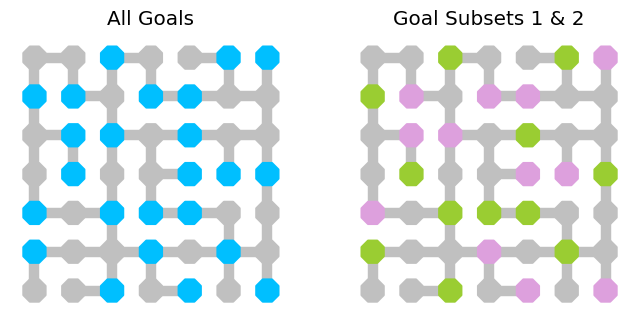

In [ ]:
##
from GridMaze.maze import plotting as mp

mp.plot_maze_series()
mp.plot_goal_subsets()

### Task Performance & Behavioural Strategies

Subjects learned the mazes well, taking very efficent paths after just a few days on each maze. 

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


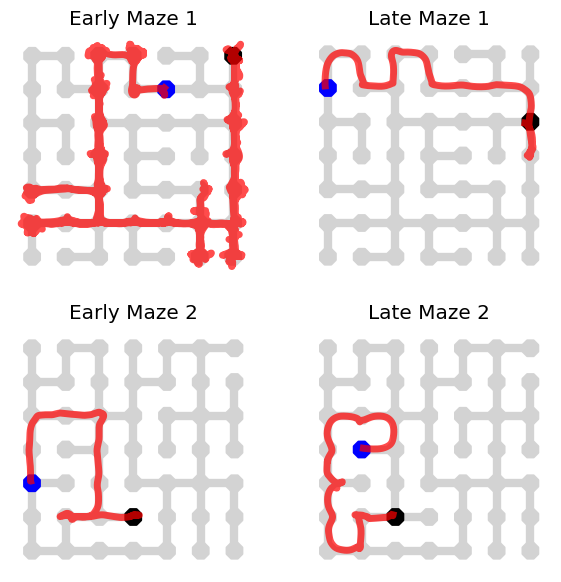

In [19]:
# plot some example trajectoires: early (exploratory), late (efficent), pairs for each maze.
from GridMaze.analysis.behaviour import trajectory_plotting as tp
from GridMaze.analysis.core import get_sessions as gs
from matplotlib import pyplot as plt

early_sessions = gs.get_maze_sessions(
    subject_IDs=["m2"], maze_names=["maze_1", "maze_2"], days_on_maze=[1], with_data=["navigation_df"]
)
late_sessions = gs.get_maze_sessions(
    subject_IDs=["m2"], maze_names=["maze_1", "maze_2"], days_on_maze=[10], with_data=["navigation_df"]
)
f, axes = plt.subplots(2, 2, figsize=(7, 7))
# optimise to find early and late to the same goal across mazes
axes[0, 0].set_title("Early Maze 1")
axes[0, 1].set_title("Late Maze 1")
axes[1, 0].set_title("Early Maze 2")
axes[1, 1].set_title("Late Maze 2")
tp.plot_trial_trajectory(early_sessions[0], trial=2, ax=axes[0, 0])
tp.plot_trial_trajectory(early_sessions[1], trial=5, ax=axes[1, 0])
tp.plot_trial_trajectory(late_sessions[1], trial=21, ax=axes[0, 1])
tp.plot_trial_trajectory(late_sessions[0], trial=40, ax=axes[1, 1])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

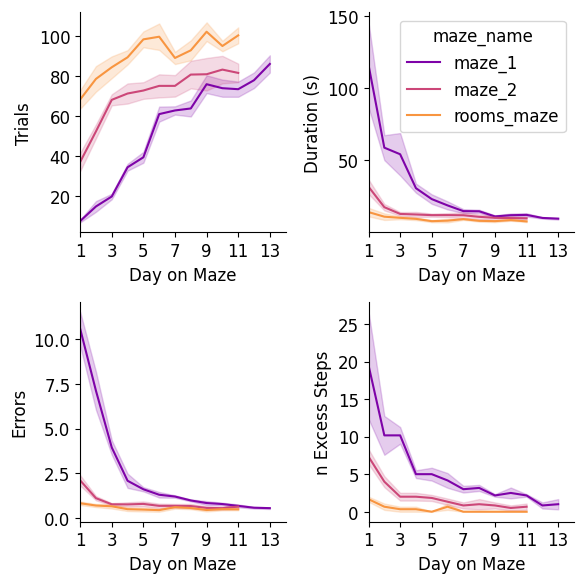

In [6]:
from GridMaze.analysis.behaviour import performance_metrics as pm

basic_behaviour_df = pm.get_basic_behaviour_df()  # loads basic behavioural data across all subjects & sessions

pm.plot_performance_metrics(basic_behaviour_df)

We can also apply a mixture-of-strategies model to tease apart how much subjects use vector-based and stucture based stratgies weight of navigational decisions
$$
Q_{net} = w_v Q_v + w_s Q_s + w_p Q_p \rightarrow softmax(P)
$$
and find the subjects use both vector-based and structure-based strategies for navigating around the maze.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

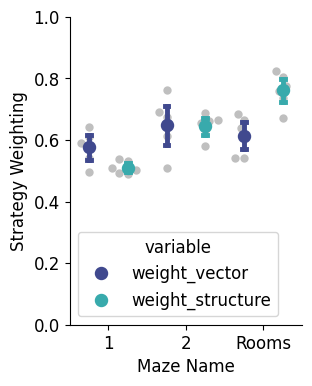

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

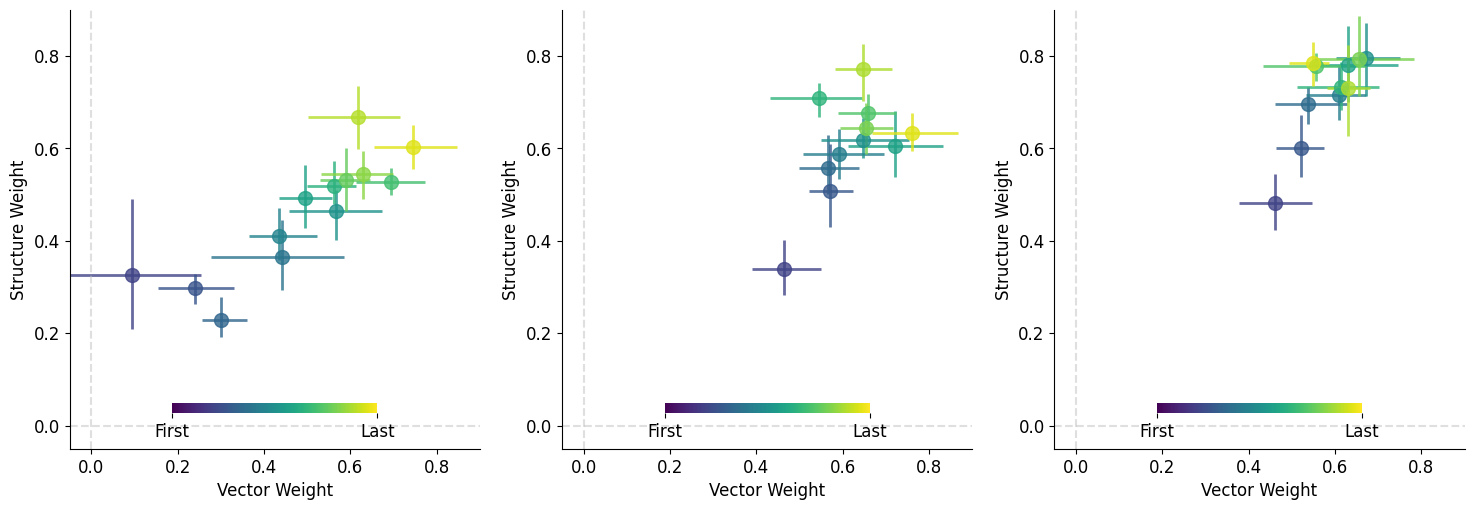

In [ ]:
from GridMaze.analysis.behaviour import navigation_strategy_modelling as nsm

# plot average strategy weight on late sessions across subjects
strategies_df = nsm.get_strategy_weights_across_subjects()
nsm.plot_strategy_weights_cross_subject(strategies_df)

# also plot the strategy weights across sessions (learning on each maze)
# with error bars that show bootstrapped random effects sem
learning_strategies_df = nsm.get_strategy_weights_across_sessions()
nsm.plot_nav_strategy_weights_over_sessions(learning_strategies_df)